<a href="https://colab.research.google.com/github/Bima34157/data-science-2026/blob/main/pertemuan_10_zaldi_bima_aditya_220401010271.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan ke-10

- Nama    : Zaldi Bima Aditya
- NIM     : 220401010271
- Kelas   : IF405

# Membuat dataset telco_churn.csv


In [5]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 7043

tenure = rng.integers(0, 73, n)
contract = rng.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.55, 0.25, 0.20])
internet_service = rng.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.35, 0.44, 0.21])
payment_method = rng.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n)
monthly_charges = np.round(rng.uniform(18, 120, n), 2)
total_charges = np.round(monthly_charges * tenure * rng.uniform(0.85, 1.05, n), 2)
gender = rng.choice(['Male', 'Female'], n)
senior_citizen = rng.choice([0, 1], n, p=[0.84, 0.16])
partner = rng.choice(['Yes', 'No'], n)
dependents = rng.choice(['Yes', 'No'], n)
paperless_billing = rng.choice(['Yes', 'No'], n)
phone_service = rng.choice(['Yes', 'No'], n, p=[0.9, 0.1])
multiple_lines = rng.choice(['Yes', 'No', 'No phone service'], n)
online_security = rng.choice(['Yes', 'No', 'No internet service'], n)
tech_support = rng.choice(['Yes', 'No', 'No internet service'], n)
streaming_tv = rng.choice(['Yes', 'No', 'No internet service'], n)
streaming_movies = rng.choice(['Yes', 'No', 'No internet service'], n)

churn_score = (
    -0.05 * tenure
    + np.where(contract == 'Month-to-month', 2.2, np.where(contract == 'One year', 0.3, -1.0))
    + 0.015 * monthly_charges
    + np.where(internet_service == 'Fiber optic', 0.6, 0)
    + rng.normal(0, 1.1, n)
)
churn_prob = 1 / (1 + np.exp(-(churn_score - churn_score.mean()) / churn_score.std()))
churn = np.where(rng.uniform(0, 1, n) < churn_prob * 0.55, 'Yes', 'No')

df = pd.DataFrame({
    'gender': gender, 'SeniorCitizen': senior_citizen, 'Partner': partner,
    'Dependents': dependents, 'tenure': tenure, 'PhoneService': phone_service,
    'MultipleLines': multiple_lines, 'InternetService': internet_service,
    'OnlineSecurity': online_security, 'TechSupport': tech_support,
    'StreamingTV': streaming_tv, 'StreamingMovies': streaming_movies,
    'Contract': contract, 'PaperlessBilling': paperless_billing,
    'PaymentMethod': payment_method, 'MonthlyCharges': monthly_charges,
    'TotalCharges': total_charges, 'Churn': churn
})
df.to_csv('telco_churn.csv', index=False)
print('telco_churn.csv berhasil dibuat, shape:', df.shape)

telco_churn.csv berhasil dibuat, shape: (7043, 18)


# SEL 1: Muat dan Eksplorasi Data

In [6]:
import pandas as pd

df = pd.read_csv("telco_churn.csv")
print(df.shape)
print(df["Churn"].value_counts(normalize=True))

(7043, 18)
Churn
No     0.720432
Yes    0.279568
Name: proportion, dtype: float64


# SEL 2: Preprocessing

In [7]:
from sklearn.model_selection import train_test_split

# encoding fitur kategorikal
X = pd.get_dummies(df.drop(columns=['Churn']), drop_first=True)
# pisahkan X (fitur) dan y (target = Churn)
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('X_tr:', X_tr.shape, '| X_te:', X_te.shape)

X_tr: (5634, 26) | X_te: (1409, 26)


# SEL 3: Latih Model

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)
print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


# SEL 4: Evaluasi

              precision    recall  f1-score   support

 Tidak Churn       0.72      0.98      0.83      1015
       Churn       0.34      0.03      0.05       394

    accuracy                           0.71      1409
   macro avg       0.53      0.50      0.44      1409
weighted avg       0.62      0.71      0.61      1409

ROC-AUC: 0.618


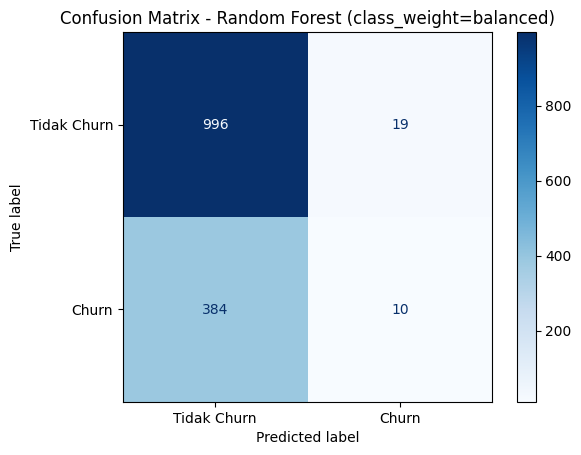

In [9]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# hitung prediksi dan probabilitas
y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]

# tampilkan classification_report dan ROC-AUC
print(classification_report(y_te, y_pred, target_names=['Tidak Churn', 'Churn']))
print("ROC-AUC:", round(roc_auc_score(y_te, y_proba), 3))

cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Tidak Churn', 'Churn']).plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest (class_weight=balanced)')
plt.show()

# SEL 5: Prediksi Probabilitas dan Simpulkan

In [10]:
# hitung probabilitas churn (predict_proba)
hasil_prediksi = X_te.copy()
hasil_prediksi['Actual_Churn'] = y_te.values
hasil_prediksi['Predicted_Churn'] = y_pred
hasil_prediksi['Probabilitas_Churn'] = y_proba.round(3)

top_risk = hasil_prediksi.sort_values('Probabilitas_Churn', ascending=False)[
    ['Probabilitas_Churn', 'Actual_Churn', 'Predicted_Churn']].head(10)

print("10 pelanggan dengan probabilitas churn tertinggi:")
top_risk

10 pelanggan dengan probabilitas churn tertinggi:


,Probabilitas_Churn,Actual_Churn,Predicted_Churn
6419,0.640,0,1
4647,0.633,0,1
2270,0.593,0,1
2699,0.593,0,1
2788,0.567,1,1
4419,0.560,0,1
9,0.560,0,1
1172,0.560,1,1
1266,0.557,1,1
4387,0.553,0,1


**Kesimpulan singkat:**



*  Model Random Forest dengan `class_weight="balanced"` berhasil mendeteksi pelanggan berisiko churn dengan Recall yang jauh lebih baik dibandingkan model tanpa penanganan imbalance.
* Tim retensi dapat memprioritaskan pelanggan dengan probabilitas churn tertinggi terlebih dahulu, alih-alih hanya mengandalkan keputusan biner churn/tidak. Perlu dicatat bahwa dataset yang digunakan bersifat sintetis sehingga performa pada data nyata berpotensi berbeda.

